In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (hamming_loss, accuracy_score,precision_score, recall_score, f1_score)
import shap
from scipy.stats import spearmanr
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 11

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Loading the dataset
df = pd.read_csv('/Users/dariusgarbau/Desktop/Thesis R Studio/vitamin_deficiency_disease_dataset_20260123.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (4000, 34)
Columns: ['age', 'gender', 'bmi', 'smoking_status', 'alcohol_consumption', 'exercise_level', 'diet_type', 'sun_exposure', 'income_level', 'latitude_region', 'vitamin_a_percent_rda', 'vitamin_c_percent_rda', 'vitamin_d_percent_rda', 'vitamin_e_percent_rda', 'vitamin_b12_percent_rda', 'folate_percent_rda', 'calcium_percent_rda', 'iron_percent_rda', 'hemoglobin_g_dl', 'serum_vitamin_d_ng_ml', 'serum_vitamin_b12_pg_ml', 'serum_folate_ng_ml', 'symptoms_count', 'symptoms_list', 'has_night_blindness', 'has_fatigue', 'has_bleeding_gums', 'has_bone_pain', 'has_muscle_weakness', 'has_numbness_tingling', 'has_memory_problems', 'has_pale_skin', 'disease_diagnosis', 'has_multiple_deficiencies']


,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,disease_diagnosis,has_multiple_deficiencies
0,79,Male,24.8,Former,None,Active,Vegetarian,High,High,Mid,...,0,0,0,0,0,0,0,0,Healthy,0
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,...,0,0,0,1,0,0,0,0,Rickets_Osteomalacia,0
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,...,1,0,0,0,0,0,0,0,Healthy,0
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,...,0,0,0,0,0,1,1,0,Anemia,0
4,63,Male,29.6,Never,None,Moderate,Vegetarian,Moderate,High,Low,...,0,0,0,0,0,0,0,0,Healthy,0


In [3]:
# Checking for missing values
print('Missing values per column:')
print(df.isnull().sum())
df.describe().transpose()

Missing values per column:
age                          0
gender                       0
bmi                          0
smoking_status               0
alcohol_consumption          0
exercise_level               0
diet_type                    0
sun_exposure                 0
income_level                 0
latitude_region              0
vitamin_a_percent_rda        0
vitamin_c_percent_rda        0
vitamin_d_percent_rda        0
vitamin_e_percent_rda        0
vitamin_b12_percent_rda      0
folate_percent_rda           0
calcium_percent_rda          0
iron_percent_rda             0
hemoglobin_g_dl              0
serum_vitamin_d_ng_ml        0
serum_vitamin_b12_pg_ml      0
serum_folate_ng_ml           0
symptoms_count               0
symptoms_list                0
has_night_blindness          0
has_fatigue                  0
has_bleeding_gums            0
has_bone_pain                0
has_muscle_weakness          0
has_numbness_tingling        0
has_memory_problems          0
has_pale_ski

,count,mean,std,min,25%,50%,75%,max
age,4000.0,50.766250,19.306237,18.0,34.000,51.00,67.0000,84.0
bmi,4000.0,26.105325,4.922746,15.0,22.800,26.20,29.4000,45.0
vitamin_a_percent_rda,4000.0,90.770850,37.083534,10.0,62.600,85.50,115.3000,219.0
vitamin_c_percent_rda,4000.0,89.199075,37.505809,10.0,60.975,83.50,113.0000,250.0
vitamin_d_percent_rda,4000.0,72.216387,42.831000,7.0,40.730,62.27,93.3175,275.6
vitamin_e_percent_rda,4000.0,89.946125,37.444649,10.0,61.700,84.05,114.1000,237.6
vitamin_b12_percent_rda,4000.0,62.743225,37.396636,10.0,32.700,55.60,84.5000,243.6
folate_percent_rda,4000.0,90.382275,37.563684,10.0,61.800,84.80,115.2000,226.6
calcium_percent_rda,4000.0,82.586300,36.359131,10.0,55.600,77.10,105.3000,232.7
iron_percent_rda,4000.0,76.211125,33.226984,10.0,51.400,71.25,95.9000,211.4


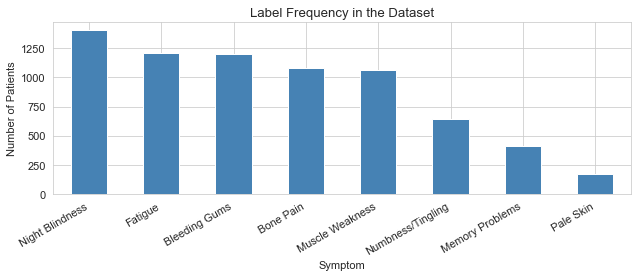

In [4]:
# Defining the 8 labels
LABEL_COLS = [
    'has_night_blindness', 'has_fatigue', 'has_bleeding_gums',
    'has_bone_pain', 'has_muscle_weakness', 'has_numbness_tingling',
    'has_memory_problems', 'has_pale_skin'
]

LABEL_NAMES = [
    'Night Blindness', 'Fatigue', 'Bleeding Gums',
    'Bone Pain', 'Muscle Weakness', 'Numbness/Tingling',
    'Memory Problems', 'Pale Skin'
]

# Plotting how often each label appears in the dataset
label_counts = df[LABEL_COLS].sum().sort_values(ascending=False)
label_counts.index = LABEL_NAMES
plt.figure(figsize=(9, 4))
label_counts.plot(kind='bar', color='steelblue')
plt.title('Label Frequency in the Dataset')
plt.xlabel('Symptom')
plt.ylabel('Number of Patients')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

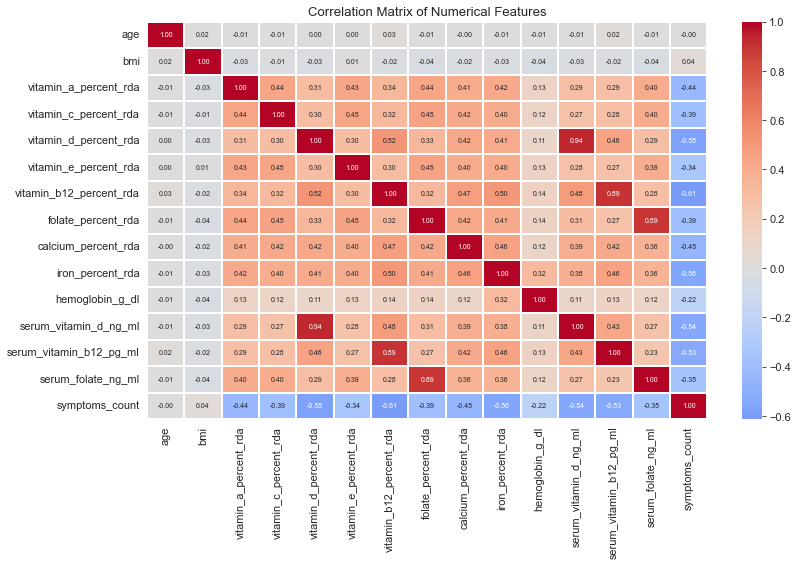

In [5]:
# Correlation heatmap of numerical features
NUMERICAL_FEATURES = [
    'age', 'bmi',
    'vitamin_a_percent_rda', 'vitamin_c_percent_rda', 'vitamin_d_percent_rda',
    'vitamin_e_percent_rda', 'vitamin_b12_percent_rda', 'folate_percent_rda',
    'calcium_percent_rda', 'iron_percent_rda',
    'hemoglobin_g_dl', 'serum_vitamin_d_ng_ml',
    'serum_vitamin_b12_pg_ml', 'serum_folate_ng_ml', 'symptoms_count'
]

plt.figure(figsize=(12, 8))
sns.heatmap(df[NUMERICAL_FEATURES].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.3, annot_kws={'size': 7})
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [6]:
# Columns that are not useful for prediction
DROP_COLS = ['symptoms_list', 'disease_diagnosis', 'has_multiple_deficiencies']

# Categorical features that need to be encoded as numbers
CATEGORICAL_FEATURES = [
    'gender', 'smoking_status', 'alcohol_consumption',
    'exercise_level', 'diet_type', 'sun_exposure',
    'income_level', 'latitude_region'
]

# Dropping unneeded columns
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# Separating features (X) and labels (y)
X = df.drop(columns=LABEL_COLS)
y = df[LABEL_COLS]

print(f'Features: {X.shape[1]}')
print(f'Samples:  {X.shape[0]}')
print(f'Labels:   {y.shape[1]}')

Features: 23
Samples:  4000
Labels:   8


In [7]:
# Encoding categorical features as numbers
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[CATEGORICAL_FEATURES] = encoder.fit_transform(X[CATEGORICAL_FEATURES])

# Saving encoded data for cross-validation
X_encoded = X.copy()

# Splitting into training set and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling numerical features
scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[NUMERICAL_FEATURES] = scaler.fit_transform(X_train[NUMERICAL_FEATURES])
X_test[NUMERICAL_FEATURES]  = scaler.transform(X_test[NUMERICAL_FEATURES])

FEATURE_NAMES = list(X_train.columns)
FEATURE_LABELS = [f.replace('_percent_rda', ' %RDA').replace('_', ' ').title()
                  for f in FEATURE_NAMES]

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print('Preprocessing complete.')

Training set: 3200 samples
Test set:     800 samples
Preprocessing complete.


In [9]:
# Initializing Random Forest
rf = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators=200,    # number of trees
        min_samples_leaf=4,  # prevents overfitting
        random_state=42,
        n_jobs=-1           
    )
)
rf.fit(X_train, y_train)
print('Random Forest done!')

Random Forest done!


In [11]:
# Initializing XGBoost
xgb = MultiOutputClassifier(
    XGBClassifier(
        n_estimators=200,    # number of boosting rounds
        max_depth=6,         # maximum tree depth
        learning_rate=0.1,   # step size
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
)
xgb.fit(X_train, y_train)
print('XGBoost done!')

XGBoost done!


In [12]:
# Initializing MLP
mlp = MultiOutputClassifier(
    MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),  # 3 hidden layers
        activation='relu',
        solver='adam',
        max_iter=300,
        early_stopping=True,       # stopping if it doesn't improve
        validation_fraction=0.1,
        random_state=42
    )
)
mlp.fit(X_train, y_train)
print('MLP done!')

/Users/dariusgarbau/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/Users/dariusgarbau/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/Users/dariusgarbau/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/Users/dariusgarbau/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/Users/dariusgarbau/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/Users/dar

MLP done!


/Users/dariusgarbau/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/Users/dariusgarbau/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


In [13]:
# Computing all evaluation metrics
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    return {
        'Model':           model_name,
        'Hamming Loss':    round(hamming_loss(y_test, y_pred), 4),
        'Subset Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Macro Precision': round(precision_score(y_test, y_pred, average='macro', zero_division=0), 4),
        'Macro Recall':    round(recall_score(y_test, y_pred, average='macro', zero_division=0), 4),
        'Macro F1':        round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4)
    }

# Evaluating all three models
results = []
for model, name in [(rf, 'Random Forest'), (xgb, 'XGBoost'), (mlp, 'MLP')]:
    results.append(evaluate_model(model, X_test, y_test, name))

results_df = pd.DataFrame(results).set_index('Model')
print('Model Performance on Test Set:')
display(results_df)

Model Performance on Test Set:


,Hamming Loss,Subset Accuracy,Macro Precision,Macro Recall,Macro F1
Model,,,,,
Random Forest,0.0838,0.5875,0.7504,0.8636,0.7993
XGBoost,0.0809,0.6100,0.7657,0.8949,0.8242
MLP,0.1000,0.5062,0.7381,0.7903,0.7614


In [16]:
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings('ignore')

# 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Indices of numerical features in the encoded, unscaled array
num_feat_idx = [list(X_encoded.columns).index(f) for f in NUMERICAL_FEATURES]

# Creating a new model instance for each fold
def make_rf():
    return MultiOutputClassifier(
        RandomForestClassifier(n_estimators=200, min_samples_leaf=4,
                               random_state=42, n_jobs=-1))

def make_xgb():
    return MultiOutputClassifier(
        XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                      random_state=42, eval_metric='logloss', verbosity=0))

def make_mlp():
    return MultiOutputClassifier(
        MLPClassifier(hidden_layer_sizes=(256, 128, 64), activation='relu',
                      solver='adam', max_iter=300, early_stopping=True,
                      validation_fraction=0.1, random_state=42))

cv_model_factories = {
    'Random Forest': make_rf,
    'XGBoost':       make_xgb,
    'MLP':           make_mlp,
}

metric_keys = ['Hamming Loss', 'Subset Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']

# Using the encoded, unscaled data, StandardScaler is applied inside each fold
X_cv = X_encoded.values
y_cv = y.values

cv_raw = {m: {k: [] for k in metric_keys} for m in cv_model_factories}

for model_name, factory in cv_model_factories.items():
    print(f'Cross-validating {model_name}...')
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_cv)):
        X_tr,  X_val  = X_cv[tr_idx].copy(), X_cv[val_idx].copy()
        y_tr,  y_val  = y_cv[tr_idx],        y_cv[val_idx]

        # Fit scaler on training fold only, prevents data leakage
        sc = StandardScaler()
        X_tr[:, num_feat_idx]  = sc.fit_transform(X_tr[:, num_feat_idx])
        X_val[:, num_feat_idx] = sc.transform(X_val[:, num_feat_idx])

        model = factory()
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        cv_raw[model_name]['Hamming Loss'].append(hamming_loss(y_val, y_pred))
        cv_raw[model_name]['Subset Accuracy'].append(accuracy_score(y_val, y_pred))
        cv_raw[model_name]['Macro Precision'].append(
            precision_score(y_val, y_pred, average='macro', zero_division=0))
        cv_raw[model_name]['Macro Recall'].append(
            recall_score(y_val, y_pred, average='macro', zero_division=0))
        cv_raw[model_name]['Macro F1'].append(
            f1_score(y_val, y_pred, average='macro', zero_division=0))
        print(f'  Fold {fold + 1}/5 done.')
    print(f'{model_name} complete.\n')

# Results Summary
cv_summary = {
    m: {k: (np.mean(v), np.std(v)) for k, v in scores.items()}
    for m, scores in cv_raw.items()
}

rows = []
for model_name, scores in cv_summary.items():
    row = {'Model': model_name}
    for metric, (mean, std) in scores.items():
        row[metric] = f'{mean:.4f} ± {std:.4f}'
    rows.append(row)

cv_df = pd.DataFrame(rows).set_index('Model')
print('5-Fold Cross-Validation Results (mean ± std):')
display(cv_df)

Cross-validating Random Forest...
  Fold 1/5 done.
  Fold 2/5 done.
  Fold 3/5 done.
  Fold 4/5 done.
  Fold 5/5 done.
Random Forest complete.

Cross-validating XGBoost...
  Fold 1/5 done.
  Fold 2/5 done.
  Fold 3/5 done.
  Fold 4/5 done.
  Fold 5/5 done.
XGBoost complete.

Cross-validating MLP...
  Fold 1/5 done.
  Fold 2/5 done.
  Fold 3/5 done.
  Fold 4/5 done.
  Fold 5/5 done.
MLP complete.

5-Fold Cross-Validation Results (mean ± std):


,Hamming Loss,Subset Accuracy,Macro Precision,Macro Recall,Macro F1
Model,,,,,
Random Forest,0.0825 ± 0.0034,0.5963 ± 0.0208,0.7664 ± 0.0059,0.8656 ± 0.0087,0.8068 ± 0.0049
XGBoost,0.0809 ± 0.0013,0.6188 ± 0.0154,0.7761 ± 0.0090,0.8693 ± 0.0156,0.8192 ± 0.0085
MLP,0.0999 ± 0.0040,0.5090 ± 0.0313,0.7507 ± 0.0090,0.7849 ± 0.0276,0.7606 ± 0.0209


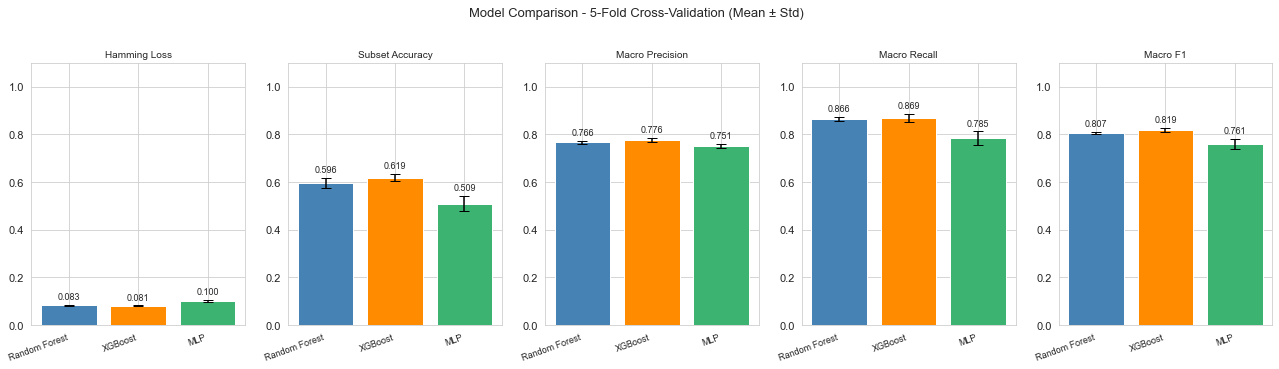

In [30]:
# Bar chart of CV mean performance with error bars (± std across folds)
metrics     = ['Hamming Loss', 'Subset Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
model_names = ['Random Forest', 'XGBoost', 'MLP']
colors      = ['steelblue', 'darkorange', 'mediumseagreen']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    means = [cv_summary[m][metric][0] for m in model_names]
    stds  = [cv_summary[m][metric][1] for m in model_names]
    x_pos = range(len(model_names))
    bars  = ax.bar(x_pos, means, yerr=stds, color=colors, capsize=5,
                   error_kw={'elinewidth': 1.5, 'ecolor': 'black'})
    ax.set_title(metric, fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                mean + std + 0.015,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison - 5-Fold Cross-Validation (Mean ± Std)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Using a sample of 200 test rows for speed
X_sample = X_test.iloc[:200]

# SHAP for Random Forest and XGBoost, TreeExplainer
def get_tree_shap_importance(model, X_sample):
    """Compute mean absolute SHAP values across all labels for tree models."""
    shap_per_label = []
    for estimator in model.estimators_:
        explainer = shap.TreeExplainer(estimator)
        sv = explainer.shap_values(X_sample)
        # Handling different SHAP output formats
        if isinstance(sv, list):
            sv = sv[1]           # take the positive class
        elif sv.ndim == 3:
            sv = sv[:, :, 1]
        shap_per_label.append(np.abs(sv))   # shape: (n_samples, n_features)
    # Average across all 8 labels, then across samples
    return np.mean(shap_per_label, axis=0).mean(axis=0)  # shape: (n_features,)

print('Computing SHAP for Random Forest...')
rf_importance = get_tree_shap_importance(rf, X_sample)
print('Computing SHAP for XGBoost...')
xgb_importance = get_tree_shap_importance(xgb, X_sample)
print('Tree SHAP done!')

Computing SHAP for Random Forest...
Computing SHAP for XGBoost...
Tree SHAP done!


In [19]:
# SHAP for MLP, KernelExplainer
import warnings
warnings.filterwarnings('ignore')
background = shap.kmeans(X_train.values, 10)

# Wrapping the MLP so it returns probabilities for all 8 labels at once
def mlp_predict(X):
    return np.column_stack(
        [est.predict_proba(X)[:, 1] for est in mlp.estimators_]
    )

mlp_explainer = shap.KernelExplainer(mlp_predict, background)
sv_mlp = mlp_explainer.shap_values(X_sample.values[:100], nsamples=50)

# Handling different SHAP output formats
n_features = len(FEATURE_NAMES)
n_labels   = 8

if isinstance(sv_mlp, list):
    # List of 8 arrays, each (n_samples, n_features) — older SHAP versions
    sv_arr = np.stack(sv_mlp, axis=0)          # -> (8, n_samples, n_features)
else:
    sv_arr = np.array(sv_mlp)
    if sv_arr.ndim == 3:
        if sv_arr.shape[-1] == n_labels:       # (n_samples, n_features, 8)
            sv_arr = sv_arr.transpose(2, 0, 1) # -> (8, n_samples, n_features)
        elif sv_arr.shape[1] == n_labels:      # (n_samples, 8, n_features)
            sv_arr = sv_arr.transpose(1, 0, 2) # -> (8, n_samples, n_features)
        # else already (8, n_samples, n_features)

# Averaging absolute SHAP values over all labels and all samples -> (n_features,)
mlp_importance = np.abs(sv_arr).mean(axis=(0, 1))
print('MLP SHAP done!')

  0%|          | 0/100 [00:00<?, ?it/s]

MLP SHAP done!


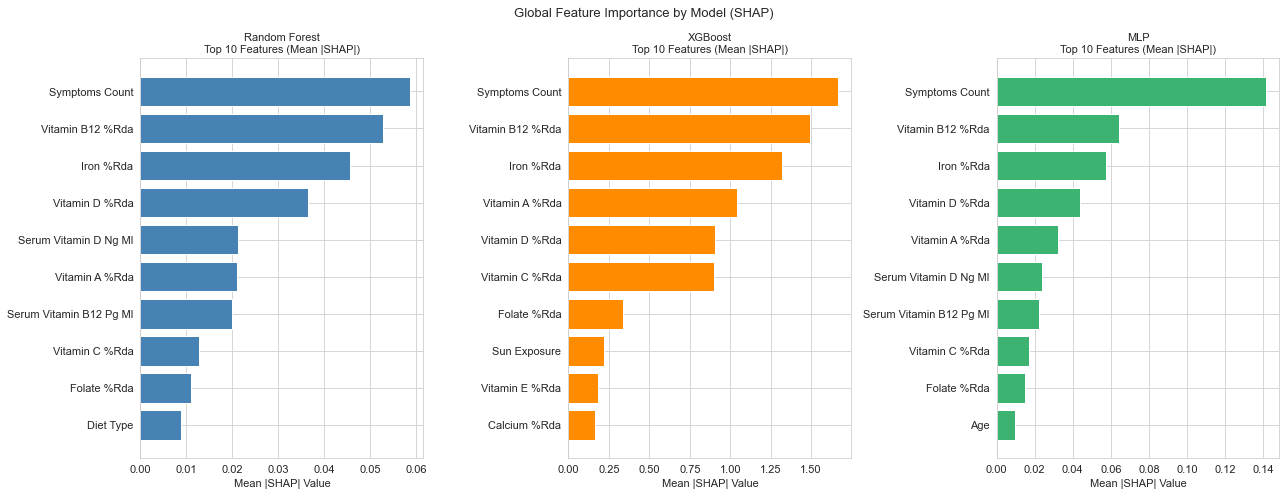

Top 5 Features per Model (Global Mean SHAP)

Random Forest:
  Symptoms Count                 0.05869
  Vitamin B12 %Rda               0.05293
  Iron %Rda                      0.04557
  Vitamin D %Rda                 0.03639
  Serum Vitamin D Ng Ml          0.02134

XGBoost:
  Symptoms Count                 1.66636
  Vitamin B12 %Rda               1.49370
  Iron %Rda                      1.31768
  Vitamin A %Rda                 1.04203
  Vitamin D %Rda                 0.90696

MLP:
  Symptoms Count                 0.14142
  Vitamin B12 %Rda               0.06422
  Iron %Rda                      0.05747
  Vitamin D %Rda                 0.04358
  Vitamin A %Rda                 0.03232


In [22]:
# Building a DataFrame of feature importances
importance_df = pd.DataFrame({
    'Random Forest': rf_importance,
    'XGBoost':       xgb_importance,
    'MLP':           mlp_importance
}, index=FEATURE_NAMES)

# Plotting top 10 features per model
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
model_colors = {'Random Forest': 'steelblue', 'XGBoost': 'darkorange', 'MLP': 'mediumseagreen'}

for ax, (model_name, color) in zip(axes, model_colors.items()):
    top10 = importance_df[model_name].nlargest(10)
    top10_labels = [FEATURE_LABELS[FEATURE_NAMES.index(f)] for f in top10.index]
    ax.barh(top10_labels[::-1], top10.values[::-1], color=color)
    ax.set_title(f'{model_name}\nTop 10 Features (Mean |SHAP|)', fontsize=11)
    ax.set_xlabel('Mean |SHAP| Value')

plt.suptitle('Global Feature Importance by Model (SHAP)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Printing top 5 per model
print('Top 5 Features per Model (Global Mean SHAP)')
for model_name in ['Random Forest', 'XGBoost', 'MLP']:
    top5 = importance_df[model_name].nlargest(5)
    print(f'\n{model_name}:')
    for feat, val in zip(top5.index, top5.values):
        label = FEATURE_LABELS[FEATURE_NAMES.index(feat)]
        print(f'  {label:<30} {val:.5f}')

In [24]:
# Clinical priority rankings (rank 1 = highest priority)
ESPEN_RANKS = {
    'hemoglobin_g_dl': 1,         'serum_vitamin_d_ng_ml': 2,
    'serum_vitamin_b12_pg_ml': 3,  'serum_folate_ng_ml': 4,
    'bmi': 5,                      'symptoms_count': 6,
    'iron_percent_rda': 7,         'vitamin_d_percent_rda': 8,
    'vitamin_b12_percent_rda': 9,  'folate_percent_rda': 10,
    'vitamin_a_percent_rda': 11,   'calcium_percent_rda': 12,
    'vitamin_c_percent_rda': 13,   'vitamin_e_percent_rda': 14,
    'diet_type': 15,               'sun_exposure': 16,
    'exercise_level': 17,          'alcohol_consumption': 18,
    'smoking_status': 19,          'age': 20,
    'gender': 21,                  'income_level': 22,
    'latitude_region': 23
}

WHO_RANKS = {
    'diet_type': 1,                'vitamin_a_percent_rda': 2,
    'iron_percent_rda': 3,         'folate_percent_rda': 4,
    'vitamin_b12_percent_rda': 5,  'vitamin_d_percent_rda': 6,
    'calcium_percent_rda': 7,      'vitamin_c_percent_rda': 8,
    'vitamin_e_percent_rda': 9,    'exercise_level': 10,
    'alcohol_consumption': 11,     'smoking_status': 12,
    'sun_exposure': 13,            'bmi': 14,
    'symptoms_count': 15,          'hemoglobin_g_dl': 16,
    'serum_vitamin_d_ng_ml': 17,   'serum_vitamin_b12_pg_ml': 18,
    'serum_folate_ng_ml': 19,      'age': 20,
    'gender': 21,                  'income_level': 22,
    'latitude_region': 23
}

print('Clinical rankings done.')

Clinical rankings done.


In [26]:
# Converting SHAP importance scores to ranks (rank 1 = most important)
def to_rank(series):
    return series.rank(ascending=False, method='average')

rank_df = pd.DataFrame({
    'Random Forest': to_rank(importance_df['Random Forest']),
    'XGBoost':       to_rank(importance_df['XGBoost']),
    'MLP':           to_rank(importance_df['MLP']),
    'ESPEN': [ESPEN_RANKS[f] for f in FEATURE_NAMES],
    'WHO':   [WHO_RANKS[f]   for f in FEATURE_NAMES]
}, index=FEATURE_NAMES)

# Compute Spearman's rho for each model vs each framework
spearman_results = []
for model in ['Random Forest', 'XGBoost', 'MLP']:
    for framework in ['ESPEN', 'WHO']:
        rho, pval = spearmanr(rank_df[model], rank_df[framework])
        spearman_results.append({
            'Model':     model,
            'Framework': framework,
            'rho':       round(rho,  4),
            'p-value':   round(pval, 4),
            'Significant (p<0.05)': 'Yes' if pval < 0.05 else 'No'
        })

spearman_df = pd.DataFrame(spearman_results)
print("Spearman's Rank Correlation - SHAP Rankings vs Clinical Guidelines:")
display(spearman_df)

Spearman's Rank Correlation - SHAP Rankings vs Clinical Guidelines:


,Model,Framework,rho,p-value,Significant (p<0.05)
0,Random Forest,ESPEN,0.6038,0.0023,Yes
1,Random Forest,WHO,0.4516,0.0305,Yes
2,XGBoost,ESPEN,0.5514,0.0064,Yes
3,XGBoost,WHO,0.5573,0.0057,Yes
4,MLP,ESPEN,0.5079,0.0134,Yes
5,MLP,WHO,0.3439,0.1081,No


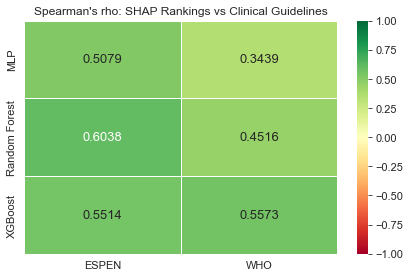

In [27]:
# Heatmap of Spearman rho values
pivot = spearman_df.pivot(index='Model', columns='Framework', values='rho')

plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn', vmin=-1, vmax=1, center=0, linewidths=0.5, annot_kws={'size': 13})
plt.title("Spearman's rho: SHAP Rankings vs Clinical Guidelines", fontsize=12)
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.savefig('spearman_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Finding features where AI ranks at least 5 positions higher than clinical guidelines
THRESHOLD = 5
label_map = dict(zip(FEATURE_NAMES, FEATURE_LABELS))

novel_findings = []
for framework in ['ESPEN', 'WHO']:
    for model in ['Random Forest', 'XGBoost', 'MLP']:
        divergence = rank_df[framework] - rank_df[model]  # positive = AI ranks higher
        for feat in FEATURE_NAMES:
            if divergence[feat] >= THRESHOLD:
                novel_findings.append({
                    'Feature':       label_map[feat],
                    'Model':         model,
                    'Framework':     framework,
                    'SHAP Rank':     int(rank_df[model][feat]),
                    'Clinical Rank': int(rank_df[framework][feat]),
                    'Divergence':    divergence[feat]
                })

novel_df = pd.DataFrame(novel_findings).sort_values('Divergence', ascending=False)
print('Features ranked higher by AI than clinical guidelines (Divergence >= 5):')
display(novel_df)

Features ranked higher by AI than clinical guidelines (Divergence >= 5):


,Feature,Model,Framework,SHAP Rank,Clinical Rank,Divergence
38,Symptoms Count,MLP,WHO,1,15,14.0
32,Symptoms Count,XGBoost,WHO,1,15,14.0
26,Symptoms Count,Random Forest,WHO,1,15,14.0
23,Serum Vitamin D Ng Ml,Random Forest,WHO,5,17,12.0
37,Serum Vitamin B12 Pg Ml,MLP,WHO,7,18,11.0
24,Serum Vitamin B12 Pg Ml,Random Forest,WHO,7,18,11.0
36,Serum Vitamin D Ng Ml,MLP,WHO,6,17,11.0
33,Age,MLP,WHO,10,20,10.0
15,Age,MLP,ESPEN,10,20,10.0
34,Income Level,MLP,WHO,13,22,9.0


In [29]:
# Showing which features consistently appear across models
consistent_novel = (
    novel_df.groupby(['Feature', 'Framework'])['Divergence']
    .agg(count='count', mean_divergence='mean')
    .reset_index()
    .sort_values('mean_divergence', ascending=False)
)
print('Features consistently ranked higher by AI (across multiple models):')
display(consistent_novel)

Features consistently ranked higher by AI (across multiple models):


,Feature,Framework,count,mean_divergence
13,Symptoms Count,WHO,3,14.000000
8,Serum Vitamin B12 Pg Ml,WHO,2,11.000000
9,Serum Vitamin D Ng Ml,WHO,3,9.666667
3,Income Level,ESPEN,2,8.000000
4,Income Level,WHO,2,8.000000
1,Age,WHO,2,7.500000
0,Age,ESPEN,2,7.500000
15,Vitamin B12 %Rda,ESPEN,3,7.000000
10,Sun Exposure,ESPEN,2,6.500000
7,Serum Folate Ng Ml,WHO,2,6.000000
